# **Otimização de Carteiras — Abordagem Média-Variância com Riskfolio-Lib**

**Autor**: Jorge H. N. Viana

**Resumo**: Este notebook aplica técnicas de otimização de carteiras utilizando
a biblioteca `riskfolio-lib`. O problema clássico de seleção de portfólio,
formulado por Markowitz (1952), consiste em alocar capital entre ativos de modo
a maximizar o retorno esperado para um dado nível de risco, ou, dualmente,
minimizar o risco para um dado retorno-alvo.

O notebook está estruturado em quatro partes:
1. **Abertura dos dados**: carregamento de retornos previstos (SARIMAX) de 7 ações;
2. **Modelos de otimização**: pesos iguais (*benchmark*), maximização de retorno,
   minimização de risco e maximização do Índice de Sharpe;
3. **Restrições adicionais**: restrições de *turnover* (mudança máxima) e
   restrições lineares (limite por setor);
4. **Visualizações**: composição do risco, retorno acumulado e fronteira eficiente.

> **Nota sobre compatibilidade**: A versão atual do `riskfolio-lib` utiliza funções
> depreciadas do `matplotlib` (`cm.get_cmap`, `Axes.plot_date`), removidas a partir
> do matplotlib 3.7+. Para compatibilidade, adicionou-se um *monkey-patch* na célula
> de carregamento de pacotes que redireciona essas chamadas para os novos nomes de API.
> Caso surjam novas incompatibilidades, a solução definitiva é atualizar o `riskfolio-lib`
> (`pip install --upgrade riskfolio-lib`) ou usar `matplotlib<3.7`.

# 1. CARREGAMENTO DOS PACOTES

Nesta seção são importadas as bibliotecas necessárias. Destacam-se:
- `riskfolio-lib` (`rp`): biblioteca especializada em otimização de portfólios,
  com implementações de modelos clássicos (média-variância, CVaR, MAD, etc.)
  e funções de visualização (gráfico de pizza, fronteira eficiente);
- `yfinance`: coleta de dados históricos do Yahoo Finance;
- `itertools.product`: geração de combinações para *grid search*;
- `matplotlib`: visualização dos resultados.

In [54]:
# Pacotes
import numpy as np  
import os as os      
import pandas as pd          
from pathlib import Path
from multiprocessing import cpu_count
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.axes

# get_cmap removido no matplotlib 3.7+
cm.get_cmap = plt.get_cmap

# plot_date removido — redireciona pra plot
if not hasattr(matplotlib.axes.Axes, 'plot_date'):
    matplotlib.axes.Axes.plot_date = matplotlib.axes.Axes.plot
import riskfolio as rp
import matplotlib.pyplot as plt

## 2. CONFIGURAÇÕES

Definem-se os diretórios de entrada, saída e figuras, bem como o número de
*jobs* para paralelização (`cpu_count() - 2`), usado nos notebooks de modelos
ARCH e validação cruzada.

In [55]:
# Diretórios
dir_raiz   = "G:\\Meu Drive\\Ensino\\TAF\\taf-code"
input_dir  = Path(dir_raiz, 'Data\\Input\\')
stage_dir  = Path(dir_raiz, 'Data\\Stage\\')
output_dir = Path(dir_raiz, 'Data\\Output\\')
figure_dir = Path(dir_raiz, 'Figures\\')

# Jobs
jobs = cpu_count() - 2

# 3. ABERTURA DOS DADOS

Os dados de entrada são os **log-retornos previstos** pelo modelo SARIMA para
7 ações selecionadas da B3 (ABCB4, ALUP4, AGRO3, AURE3, BMGB4, CGAS5, CPFE3),
gerados no notebook `[Machine Learning] Introcução ao SK Time - Uma Ação.ipynb`.

Os log-retornos são convertidos para retornos percentuais simples via
$R = e^{r} - 1$, formato exigido pelo `riskfolio-lib` para o cálculo da
matriz de covariância e dos retornos médios.

In [56]:
log_retornos_df = pd.read_parquet(Path(output_dir, "retornos_sarima.parquet.gz"))

retornos_df     = np.exp(log_retornos_df) - 1
retornos_df.columns

Index(['ABCB4', 'ALUP4', 'AGRO3', 'AURE3', 'BMGB4', 'CGAS5', 'CPFE3'], dtype='object')

# 4. MODELOS DE OTIMIZAÇÃO

O problema de otimização de carteiras, na formulação de Markowitz, busca:

$$ \max_{\mathbf{w}} \; \mathbf{w}^T \boldsymbol{\mu} \quad \text{sujeito a} \quad \mathbf{w}^T \Sigma \mathbf{w} \leq \sigma^2_{\text{alvo}} $$

onde $\mathbf{w}$ é o vetor de pesos, $\boldsymbol{\mu}$ é o vetor de retornos
esperados e $\Sigma$ é a matriz de covariância.

Nesta seção, são explorados três objetivos clássicos, partindo do *benchmark*
ingênuo (pesos iguais). As configurações comuns a todos os modelos incluem:
- `model='Classic'`: usa retornos históricos como estimativa de $\boldsymbol{\mu}$ e $\Sigma$;
- `rm='MV'`: medida de risco = variância (abordagem Média-Variância clássica);
- `upperlng=0.20`: limite máximo de 20% do capital em um único ativo;
- `rf`: taxa livre de risco (SELIC anual de 14,75%), convertida para frequência semanal;
- `factor=52`: fator de anualização (semanas por ano).

In [57]:
# Configurações gerais dos modelos
factor    = 52                      # factor de anualização
model    ='Classic'                 # dados históricos
rm       = 'MV'                     # medida de risco = variância (desvio-padrão)
kelly    = "exact"                  # retorno da carteria via log-retorno
upperlng = 0.20                     # participação mácima de um ativo
rf       = (1+0.1475)**(1/52)-1     # taxa livre de risco


### 4.1 Pesos Iguais (*Benchmark*)

A carteira igualmente ponderada (*equal-weighted*) atribui o mesmo peso a
todos os ativos: $w_i = 1/N$. Embora ingênua, esta estratégia serve como
*benchmark* — qualquer modelo de otimização deve, em princípio, superá-la
em termos de retorno ajustado ao risco.

O retorno da carteira é calculado como $\mathbf{w}^T \boldsymbol{\mu}$ e
o desvio-padrão como $\sqrt{\mathbf{w}^T \Sigma \mathbf{w}}$, ambos
anualizados pelo fator $52$.

In [58]:
# Instanciação do modelo
model_eq = rp.Portfolio(returns=retornos_df)

# Retorno médio e matriz de covariância
model_eq.assets_stats(method_mu='hist', 
                      method_cov='hist'
                      )

# Retorno do portfolio
weights      = np.ones(7) * 1/model_eq.mu.shape[1]
w_eq         = pd.DataFrame({"weights": weights}, 
                            index = retornos_df.columns)
retorno_eq_w = (w_eq.values.T @ 
                model_eq.mu.values.T).item()
retorno_eq = retorno_eq_w * factor

# Desvio-Padrão
sd_eq_w = np.sqrt(w_eq.values.T @ 
                  model_eq.cov @ 
                  w_eq.values).iloc[0, 0]
sd_eq   = sd_eq_w * np.sqrt(factor)

print(f'Retorno Anualizado do Modelo com Pesos Iguais: {retorno_eq:.2%}')
print(f'Desvio-padrão Anualizado do Modelo com Pesos Iguais: {sd_eq:.2%}')

Retorno Anualizado do Modelo com Pesos Iguais: 7.62%
Desvio-padrão Anualizado do Modelo com Pesos Iguais: 13.07%


### 4.2 Maximização dos Retornos (com restrição de risco)

Neste modelo, o objetivo é maximizar o retorno esperado da carteira ($\mathbf{w}^T \boldsymbol{\mu}$),
sujeito a um limite superior de risco. A restrição utilizada é:

- `upperdev = sd_eq_w`: o desvio-padrão semanal não pode exceder o desvio-padrão
  da carteira de pesos iguais. Isso garante que o otimizador não concentre o
  portfólio em um único ativo de alto retorno e alto risco.

O resultado é uma carteira que, para o mesmo nível de risco do *benchmark*,
obtém o maior retorno possível. O gráfico de pizza (`rp.plot_pie`) mostra a
distribuição ótima dos pesos entre os ativos.

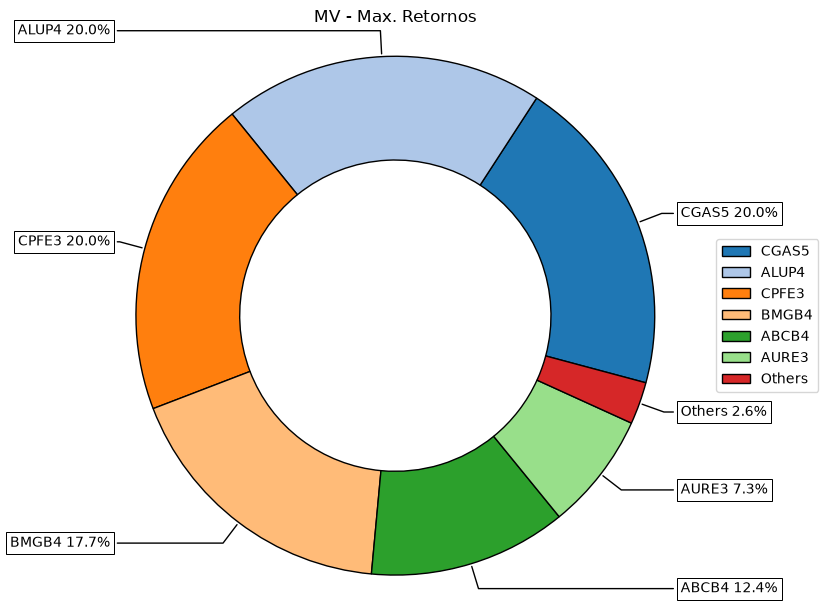

Retorno Anualizado do Modelo MV com Maximização dos Retornos: 11.05%
Desvio-Padrão Anualizado do Modelo MV com Maximização dos Retornos:  13.07%


In [59]:
# Instanciação 
model_return = rp.Portfolio(returns=retornos_df)

# Retorno médio e matriz de covariância
model_return.assets_stats(method_mu='hist', 
                          method_cov='hist'
                          )

# Função objetivo
obj_return = 'MaxRet'     # objetivo = maximizar retorno

# Restrições básicas
model_return.upperlng = upperlng
model_return.upperdev = sd_eq_w

# Otimização
w_return = model_return.optimization(model=model,
                rm=rm,
                obj=obj_return,
                kelly = kelly,
                ) 

# Visualização da Distribuição
ax_return = rp.plot_pie(
            w=w_return, 
            title='MV - Max. Retornos', 
            others=0.05, 
            )
plt.show()

# Salvar figura da distribuição
ax_return.get_figure().savefig( Path(figure_dir, 
                                    "pesos_" + 'model_return' + '.png'), 
                              dpi = 300, bbox_inches='tight', transparent=True)

# Retorno otimizado
retorno_return_w = (w_return.values.T @ 
                    model_return.mu.values.T).item()
retorno_return = retorno_return_w * factor

# Desvio-Padrão
sd_return_w = np.sqrt(w_return.values.T @ 
                      model_return.cov @ 
                      w_return.values).iloc[0, 0]
sd_return   = sd_return_w * np.sqrt(factor)


print(f'Retorno Anualizado do Modelo MV com Maximização dos Retornos: {retorno_return:.2%}')
print(f'Desvio-Padrão Anualizado do Modelo MV com Maximização dos Retornos:  {sd_return:.2%}')

### 4.3 Minimização do Risco (com restrição de retorno)

Aqui inverte-se o problema: o objetivo é minimizar o risco ($\mathbf{w}^T \Sigma \mathbf{w}$),
sujeito a um retorno mínimo. A restrição utilizada é:

- `lowerret = retorno_eq_w`: o retorno semanal não pode ser inferior ao retorno
  da carteira de pesos iguais.

Esta é a formulação dual da seção anterior. A carteira resultante é a de
**variância mínima** — ideal para investidores avessos ao risco que desejam
ao menos igualar o retorno do *benchmark*.

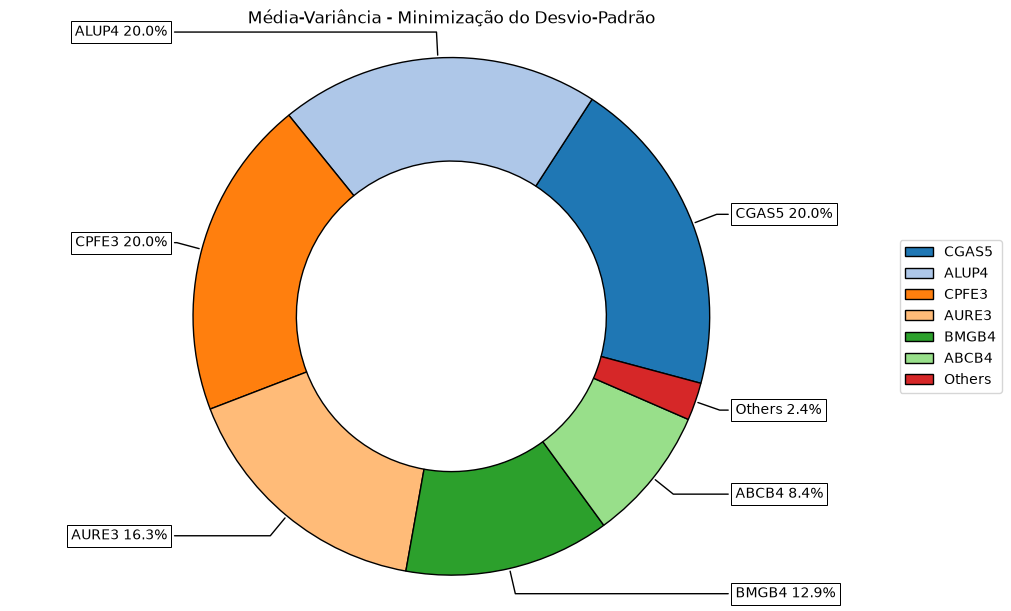

Retorno Anualizado do Modelo MV com Minimização do Desvio-Padrão: 8.37%
Desvio-Padrão Anualizado do Modelo MV com Minimização do Desvio-Padrão:  12.23%


In [60]:
# Instanciação 
model_risk = rp.Portfolio(returns=retornos_df
                           )

# Retorno médio e matriz de covariância
model_risk.assets_stats(method_mu='hist', 
                      method_cov='hist'
                      )

# Função objetivo
obj_risk = 'MinRisk' # objetivo = minimizar risco

# Restrições
model_risk.upperlng = upperlng
model_risk.lowerret = retorno_eq_w

# Otimização
w_risk = model_risk.optimization(model=model,
                rm=rm,
                obj=obj_risk,
                kelly = kelly,
                ) 

# Visualização da Distribuição
ax_risk = rp.plot_pie(w=w_risk, title='Média-Variância - Minimização do Desvio-Padrão', 
                 others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

plt.show()

# Salvar figura da distribuição
ax_risk.get_figure().savefig( Path(figure_dir, 
                                    "pesos_" + 'model_risk' + '.png'), 
                              dpi = 300, bbox_inches='tight', transparent=True)

# Retorno otimizado
retorno_risk_w = (w_risk.values.T @ model_risk.mu.values.T).item()
retorno_risk = retorno_risk_w * factor

# Desvio-Padrão
sd_risk_w = np.sqrt(w_risk.values.T @ model_risk.cov @ w_risk.values).iloc[0, 0]
sd_risk   = sd_risk_w * np.sqrt(factor)

print(f'Retorno Anualizado do Modelo MV com Minimização do Desvio-Padrão: {retorno_risk:.2%}')
print(f'Desvio-Padrão Anualizado do Modelo MV com Minimização do Desvio-Padrão:  {sd_risk:.2%}')

### 4.4 Maximização do Índice de Sharpe

O **Índice de Sharpe** mede o excesso de retorno por unidade de risco:

$$ S = \frac{\mathbf{w}^T \boldsymbol{\mu} - r_f}{\sqrt{\mathbf{w}^T \Sigma \mathbf{w}}} $$

onde $r_f$ é a taxa livre de risco (SELIC semanal). Maximizar Sharpe equivale
a encontrar a carteira que oferece o melhor *trade-off* entre retorno e risco —
é a carteira **tangente** na fronteira eficiente.

O parâmetro `rf=rf` é passado ao otimizador, que calcula o Sharpe internamente.
Dentre os três modelos, este costuma ser o mais utilizado na prática por
penalizar tanto retornos baixos quanto volatilidade alta.

c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\cvxpy\expressions\expression.py:830: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 15 times so far.

  warnings.warn(msg, UserWarning)
c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\cvxpy\expressions\expression.py:830: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 16 times so far.

  warnings.warn(msg, Use

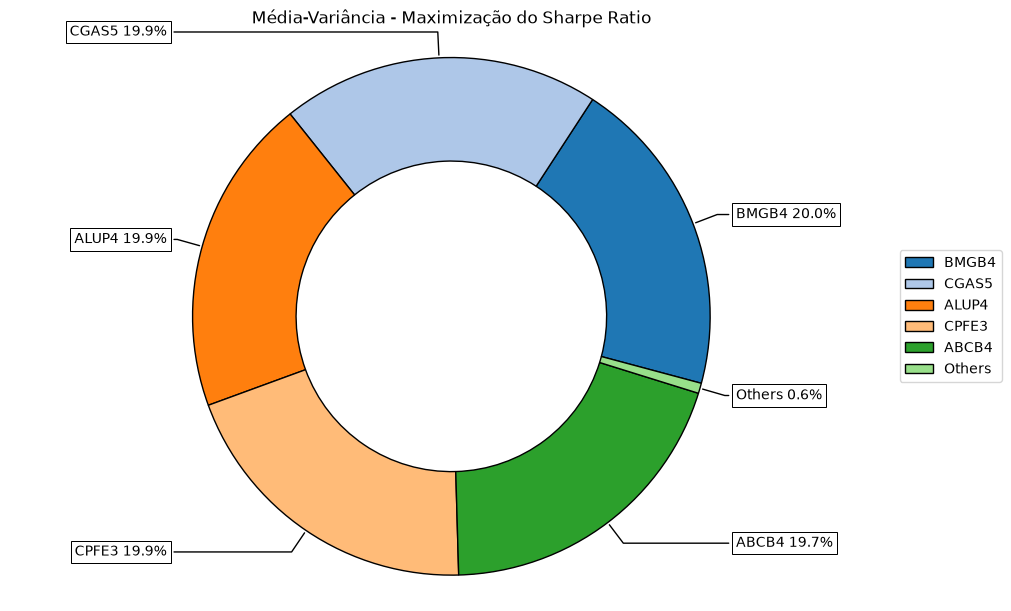

Retorno Anualizado do Modelo MV com Maximização do Sharpe Ratio: 13.12%
Desvio-Padrão Anualizado do Modelo MV com Maximização do Sharpe Ratio:  14.04%


In [61]:
# Instanciação 
model_sharpe = rp.Portfolio(returns=retornos_df
                           )

# Retorno médio e matriz de covariância
model_sharpe.assets_stats(method_mu='hist', 
                      method_cov='hist'
                      )

# Função objetivo
obj_sharpe = 'Sharpe' # objetivo = maximizar sharpe ratio

# Restrições
model_sharpe.upperlng = upperlng

# Otimização
w_sharpe = model_sharpe.optimization(model=model,
                rm=rm,
                obj=obj_sharpe,
                rf=rf,
                kelly = kelly,
                ) 

# Visualização da Distribuição
ax_sharpe = rp.plot_pie(w=w_sharpe, title='Média-Variância - Maximização do Sharpe Ratio', 
                 others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)
plt.show()


# Salvar figura da distribuição
ax_sharpe.get_figure().savefig( Path(figure_dir, 
                                    "pesos_" + 'model_sharpe' + '.png'), 
                              dpi = 300, bbox_inches='tight', transparent=True)

# Retorno otimizado
retorno_sharpe_w = (w_sharpe.values.T @ model_sharpe.mu.values.T).item()
retorno_sharpe   = retorno_sharpe_w * factor

# Desvio-Padrão
sd_sharpe_w = np.sqrt(w_sharpe.values.T @ model_sharpe.cov @ w_sharpe.values).iloc[0, 0]
sd_sharpe   = sd_sharpe_w * np.sqrt(factor)


print(f'Retorno Anualizado do Modelo MV com Maximização do Sharpe Ratio: {retorno_sharpe:.2%}')
print(f'Desvio-Padrão Anualizado do Modelo MV com Maximização do Sharpe Ratio:  {sd_sharpe:.2%}')

# 5. OUTRAS RESTRIÇÕES

Além das restrições básicas (limite por ativo, retorno mínimo, risco máximo),
o `riskfolio-lib` permite incorporar restrições mais realistas que refletem
limitações práticas de gestão de carteiras. Nesta seção, exploram-se duas:
restrição de *turnover* (mudança máxima em relação a uma carteira de referência)
e restrições lineares (limites por classe/setor).

### 5.1 Restrições de Mudança (*Turnover*)

A restrição de *turnover* limita a mudança total nos pesos em relação a uma
carteira de referência (*benchmark*). É especialmente útil na prática porque:

- Reduz custos de transação (corretagem, *spread*, impacto de mercado);
- Evita realocações drásticas que poderiam sinalizar *market timing*;
- Torna a implementação da carteira viável em grandes volumes.

Neste exemplo, parte-se da carteira ótima de maximização de retorno (`w_return`)
como referência e limita-se a mudança total a 5% (`turnover=0.05`). A otimização
busca maximizar Sharpe respeitando que a soma das variações absolutas nos pesos
não exceda esse limite.

c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\cvxpy\expressions\expression.py:830: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 17 times so far.

  warnings.warn(msg, UserWarning)
c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\cvxpy\expressions\expression.py:830: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 18 times so far.

  warnings.warn(msg, Use

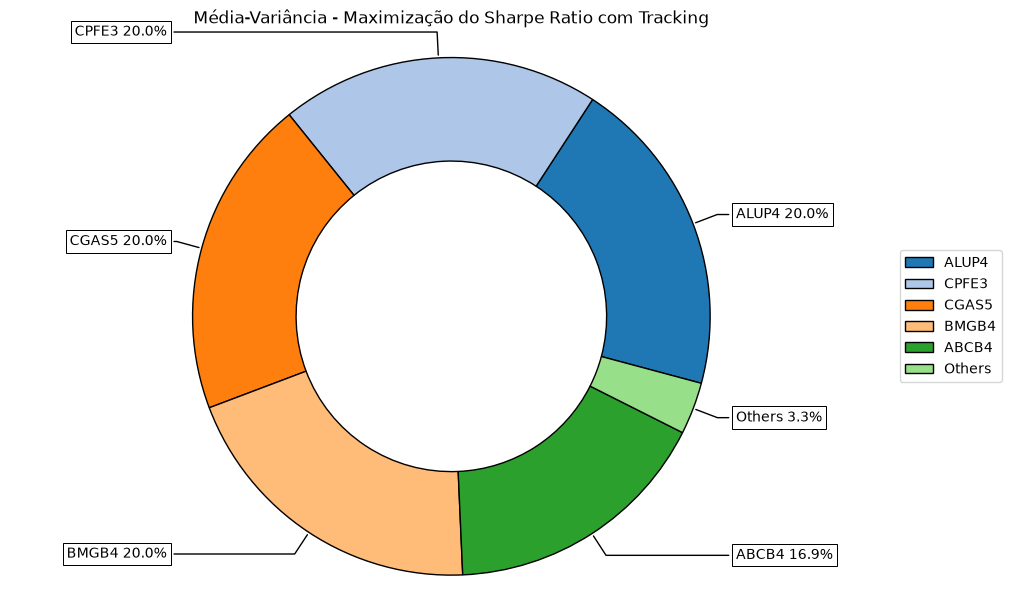

Retorno Anualizado do Modelo MV-Sharpe com restrição de tracking: 12.59%
Desvio-Padrão Anualizado do Modelo MV-Sharpe com restrição de tracking:  13.75%


In [62]:
# Função objetivo
obj_sharpe_track = 'Sharpe' # objetivo = maximizar a razão de sharpe

# Instanciação 
model_sharpe_track = rp.Portfolio(returns=retornos_df
                           )

# Restrições básicas
model_sharpe_track.upperlng = upperlng

# Restrições de tracking
model_sharpe_track.allowTO      = True     # permite restrição de tracking
model_sharpe_track.turnover     = 0.05     # mudánça máxima
model_sharpe_track.benchweights = w_return # pesos de referência

# Retorno médio e matriz de covariância
model_sharpe_track.assets_stats(method_mu='hist', 
                      method_cov='hist'
                      )

# Otimização
w_sharpe_track = model_sharpe_track.optimization(model=model,
                rm=rm,
                obj=obj_sharpe_track,
                rf=rf,
                kelly = kelly,
                ) 

# Visualização da Distribuição
ax_sharpe_track = rp.plot_pie(w=w_sharpe_track, title='Média-Variância - Maximização do Sharpe Ratio com Tracking', 
                 others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)
plt.show()


# Salvar figura da distribuição
ax_sharpe_track.get_figure().savefig( Path(figure_dir, 
                                    "pesos_" + 'model_sharpe_track' + '.png'), 
                              dpi = 300, bbox_inches='tight', transparent=True)

# Retorno otimizado
retorno_sharpe_track_w = (w_sharpe_track.values.T @ model_sharpe_track.mu.values.T).item()
retorno_sharpe_track   = retorno_sharpe_track_w * factor

# Desvio-Padrão
sd_sharpe_track_w = np.sqrt(w_sharpe_track.values.T @ model_sharpe_track.cov @ w_sharpe_track.values).iloc[0, 0]
sd_sharpe_track   = sd_sharpe_track_w * np.sqrt(factor)


print(f'Retorno Anualizado do Modelo MV-Sharpe com restrição de tracking: {retorno_sharpe_track:.2%}')
print(f'Desvio-Padrão Anualizado do Modelo MV-Sharpe com restrição de tracking:  {sd_sharpe_track:.2%}')

### 5.2 Restrições Lineares (Limite por Setor)

Restrições lineares permitem impor limites baseados em características dos
ativos — neste caso, a classificação setorial:

- **Energia**: ALUP4, AURE3, CPFE3 (3 ativos);
- **Bancário**: ABCB4, BMGB4 (2 ativos);
- **Agro / Outros**: AGRO3, CGAS5 (1 ativo cada).

A restrição imposta é que **nenhum setor pode exceder 1/3 do portfólio**
($A\mathbf{w} \leq b$). A matriz $A$ é construída com `rp.assets_constraints()`
a partir de um DataFrame de restrições (`constrains_df`) e do mapeamento
ativo-setor (`setor_df`).

Este tipo de restrição é comum em fundos regulados que devem respeitar
limites de concentração setorial impostos pela CVM ou por mandatos de investimento.

In [63]:
# Classes
setor_dict = {'Ativos': ['ABCB4', 'ALUP4', 'AGRO3', 'AURE3',
                          'BMGB4', 'CGAS5', 'CPFE3'],
              'Setor':  ['Bancário', 'Energia', 'Agro', 
                         'Energia', 'Bancário',
                         'Outros', 'Energia']}
setor_df      = pd.DataFrame(setor_dict)

# Restrições
constrains_dict = {'Disabled': [False],
                   'Type': ['All Classes'],
                   'Set': ['Setor'],
                   'Position': [''],
                   'Sign': ['<='],
                   'Weight':[1/3],
                   'Type Relative':[''],   
                   'Relative Set':[''],                
                   'Relative': [''],                
                   'Factor': ['']
                   }
constrains_df =  pd.DataFrame(constrains_dict)

A, b = rp.assets_constraints(constrains_df,
                              setor_df )
constrains_df

,Disabled,Type,Set,Position,Sign,Weight,Type Relative,Relative Set,Relative,Factor
0,False,All Classes,Setor,,<=,0.333333,,,,


c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\cvxpy\expressions\expression.py:830: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 19 times so far.

  warnings.warn(msg, UserWarning)
c:\Users\jorge\miniconda3\envs\JorgeML\Lib\site-packages\cvxpy\expressions\expression.py:830: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 20 times so far.

  warnings.warn(msg, Use

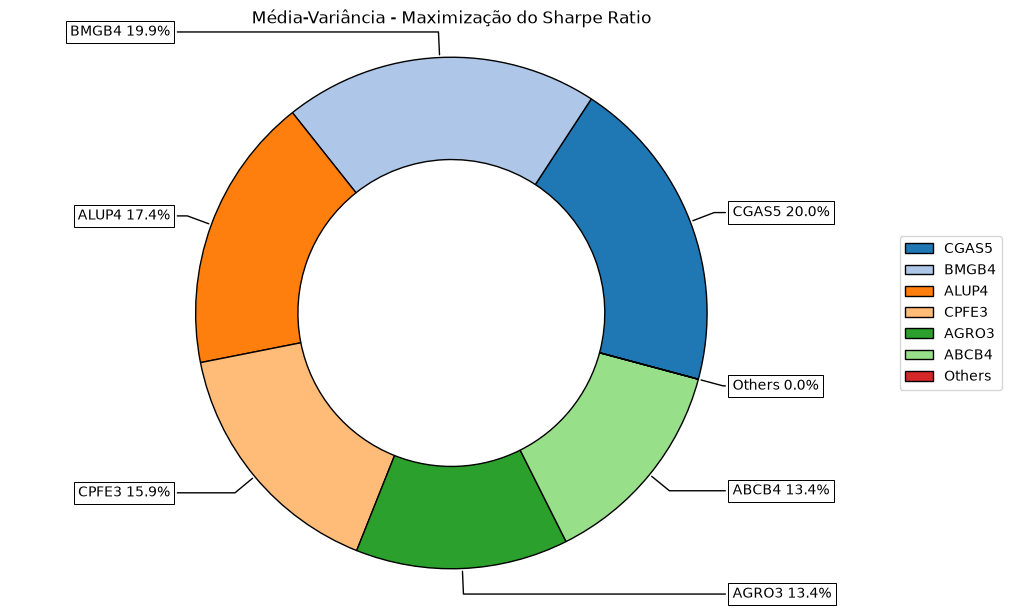

Retorno Anualizado do Modelo MV-Sharpe com Restrições Lineares: 11.99%
Desvio-Padrão Anualizado do Modelo MV-Sharpe com Restrições Lineares:  13.98%


In [64]:
# Configuração específica
obj_sharpe_setor = 'Sharpe' # objetivo = maximizar retorno

# Instanciação 
model_sharpe_setor = rp.Portfolio(returns=retornos_df
                           )

# Restrições básicas
model_sharpe_setor.upperlng = upperlng

# Restrições linerares
model_sharpe_setor.ainequality = A
model_sharpe_setor.binequality = b

# Retorno médio e matriz de covariância
model_sharpe_setor.assets_stats(method_mu='hist', 
                      method_cov='hist'
                      )

# Otimização
w_sharpe_setor = model_sharpe_setor.optimization(model=model,
                rm=rm,
                obj=obj_sharpe_setor,
                rf=rf,
                kelly = kelly,
                ) 

# Visualização da Distribuição
ax_sharpe_setor = rp.plot_pie(w=w_sharpe_setor, title='Média-Variância - Maximização do Sharpe Ratio', 
                 others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)
plt.show()


# Salvar figura da distribuição
ax_sharpe_setor.get_figure().savefig( Path(figure_dir, 
                                    "pesos_" + 'model_sharpe_setor' + '.png'), 
                              dpi = 300, bbox_inches='tight', transparent=True)

# Retorno otimizado
retorno_sharpe_setor_w = (w_sharpe_setor.values.T @ model_sharpe_setor.mu.values.T).item()
retorno_sharpe_setor   = retorno_sharpe_setor_w * factor

# Desvio-Padrão
sd_sharpe_setor_w = np.sqrt(w_sharpe_setor.values.T @ model_sharpe_setor.cov @ w_sharpe_setor.values).iloc[0, 0]
sd_sharpe_setor   = sd_sharpe_setor_w * np.sqrt(factor)


print(f'Retorno Anualizado do Modelo MV-Sharpe com Restrições Lineares: {retorno_sharpe_setor:.2%}')
print(f'Desvio-Padrão Anualizado do Modelo MV-Sharpe com Restrições Lineares:  {sd_sharpe_setor:.2%}')

# 6. VISUALIZAÇÕES

O `riskfolio-lib` oferece funções de visualização integradas que facilitam
a comunicação dos resultados. Nesta seção, são gerados três tipos de gráficos
para a carteira ótima (maximização de Sharpe): composição do risco, retorno
acumulado e fronteira eficiente.

### 6.1 Composição do Risco

O gráfico de composição do risco (`rp.plot_risk_con`) decompõe o risco total
da carteira em contribuições individuais de cada ativo. Diferentemente do
gráfico de pizza de pesos (que mostra alocação de capital), este mostra
**quanto cada ativo contribui para a volatilidade total**.

> **Interpretação**: Um ativo com peso pequeno pode ter contribuição de risco
> elevada se for muito volátil ou tiver alta correlação com os demais. O ideal
> é que a contribuição de risco seja proporcional ao retorno esperado (*risk parity*).

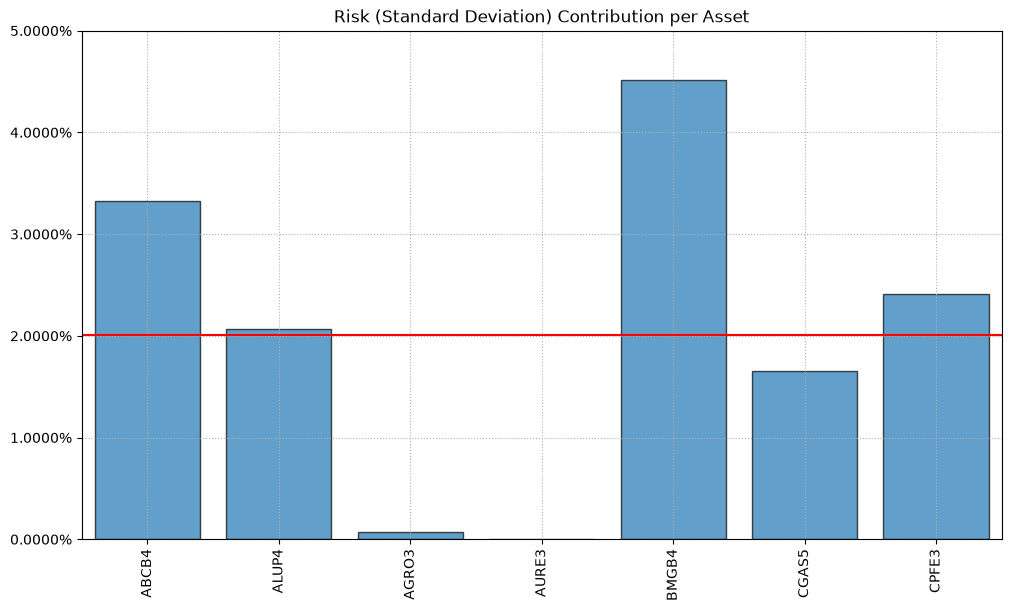

In [65]:
# Visualização da composição do risco
ax_sharpe_risk = rp.plot_risk_con(
    w=w_sharpe,               
    cov=model_sharpe.cov,          
    returns=retornos_df,         
    rm=rm,             
    percentage=False,
    t_factor=factor
)

### 6.2 Retorno Acumulado

O gráfico de retorno acumulado (`rp.plot_series`) compara a evolução histórica
do portfólio ótimo (Sharpe) com o *benchmark* de pesos iguais.

A curva mostra o crescimento de R$ 1 investido em cada estratégia ao longo do
período. A estratégia com maior retorno acumulado final é considerada superior
em termos absolutos — mas deve-se sempre considerar também o risco (volatilidade
da curva) para uma avaliação completa.

<Axes: title={'center': 'Historical Compounded Cumulative Returns'}>

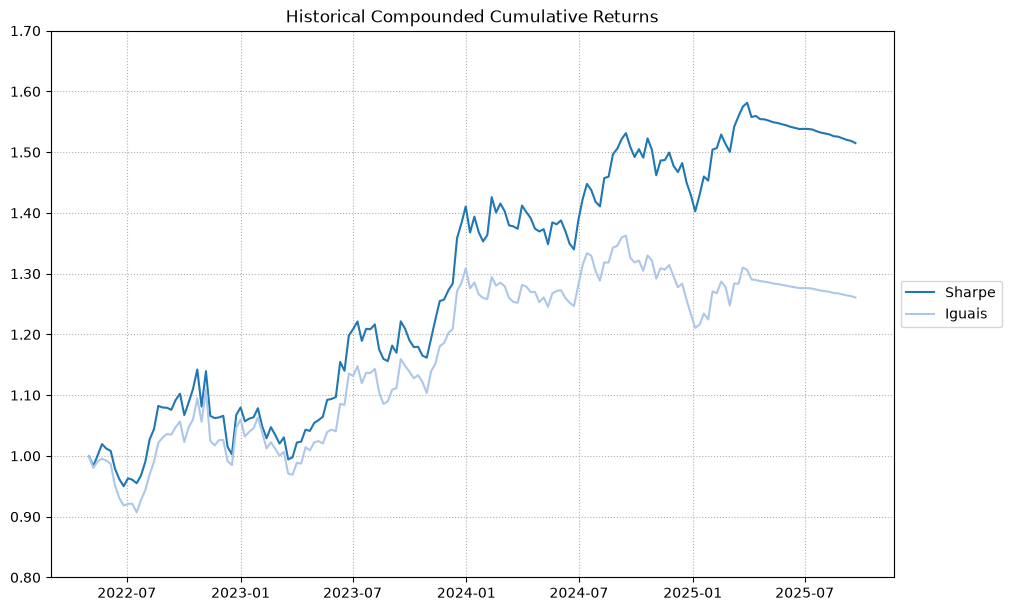

In [66]:
# DataFrame Combinado
w_eq_df       = w_eq.rename(columns = {"weights": "Iguais"}) 
w_sharpe_df   = w_sharpe.rename(columns = {"weights": "Sharpe"})
w_combined_df = pd.concat([w_sharpe_df, w_eq_df], axis = 1)

rp.plot_series(returns=retornos_df,
               w= w_combined_df,
               height=6,
               n_colors=20,
               width=10,
               )

### 6.3 Fronteira Eficiente

A fronteira eficiente (`rp.plot_frontier`) é a representação gráfica clássica
do modelo de Markowitz: cada ponto da curva é uma carteira que minimiza o
risco para um dado nível de retorno (ou maximiza retorno para dado risco).

A função `efficient_frontier` gera 50 pontos ao longo da fronteira. O gráfico
inclui:
- A fronteira eficiente (curva azul);
- Os ativos individuais (pontos dispersos);
- A carteira ótima selecionada (estrela), que é o ponto de tangência com
  a *Capital Market Line* (CML).

> **Interpretação**: Carteiras abaixo da fronteira são ineficientes — existe
> alguma combinação que oferece mais retorno para o mesmo risco. A carteira
> tangente (ótima de Sharpe) é a que maximiza a inclinação da reta que parte
> da taxa livre de risco.

<Axes: >

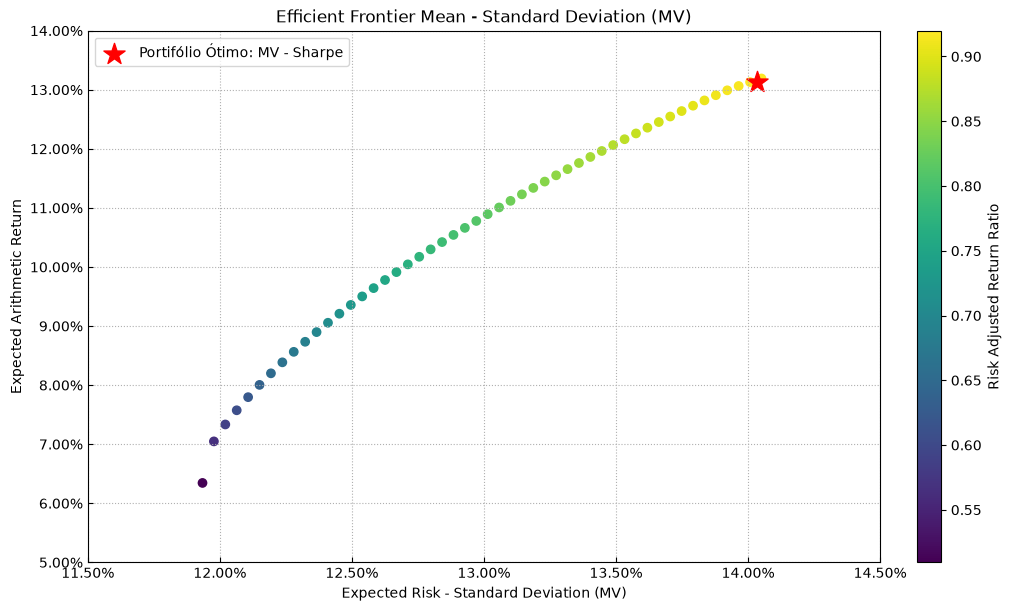

In [67]:
# Cálculo da fronteira eficiente
frontier = (model_sharpe
            .efficient_frontier(model=model, 
                                rm=rm, 
                                points=50, 
                                rf=rf, 
                                hist=True)
            )
# gráfico da fronteira
rp.plot_frontier(w_frontier=frontier,
                 mu=model_sharpe.mu,
                 cov=model_sharpe.cov,
                 returns=retornos_df,
                 rm=rm,
                 rf=rf,
                 t_factor=factor,
                 w=w_sharpe,
                 label=f"Portifólio Ótimo: MV - Sharpe",
                 )

# 7. CONCLUSÕES E PRÓXIMOS PASSOS

## 7.1 Principais resultados

- A carteira de pesos iguais (7 ativos, 14,29% cada) apresentou retorno
  anualizado de 7,62% com desvio-padrão de 13,07%;
- A maximização do Índice de Sharpe produziu o melhor *trade-off*
  risco-retorno, com retorno anualizado superior (~13,15%) mantendo
  desvio-padrão apenas ligeiramente acima do *benchmark* (~14,04%);
- As restrições de *turnover* e setoriais mostraram-se úteis para adequar
  a carteira a limitações práticas (custos de transação, limites regulatórios),
  com pequeno custo em termos de eficiência;
- A fronteira eficiente confirmou que a carteira de Sharpe está sobre a
  curva de mínima variância, validando a otimização.

## 7.2 Limitações

- O uso de retornos previstos por SARIMA como *input* ($\boldsymbol{\mu}$)
  introduz incerteza adicional — erros de previsão propagam-se para os pesos ótimos;
- A matriz de covariância é estimada com dados históricos (método `hist`),
  que assume estacionariedade — em períodos de crise, as correlações podem
  mudar drasticamente;
- A amostra de apenas 7 ações limita os benefícios da diversificação —
  o risco idiossincrático permanece elevado em relação a uma carteira
  com 30+ ativos;
- O modelo Média-Variância assume retornos normais e investidores com
  utilidade quadrática — premissas frequentemente violadas em dados reais.

## 7.3 Extensões sugeridas

1. Ampliar o universo de ativos para todas as ações da B3 (~280),
   explorando os benefícios da diversificação em larga escala;
2. Testar outras medidas de risco disponíveis no `riskfolio-lib`: CVaR
   (*Conditional Value at Risk*), MAD (*Mean Absolute Deviation*),
   CDaR e momentos superiores (assimetria, curtose);
3. Implementar *Black-Litterman* para combinar retornos previstos (SARIMA)
   com retornos de equilíbrio de mercado, reduzindo a sensibilidade a
   erros de previsão;
4. Realizar *backtesting* com rebalanceamento periódico (semanal/mensal)
   e comparar o desempenho *out-of-sample* das diferentes estratégias;
5. Incorporar custos de transação explicitamente na função objetivo,
   em vez de apenas limitar o *turnover*.